# UMAG — Amazon Electronics (MerRec Architecture) v6


## Cell 1 — Imports & Config

In [ ]:
import ast, json, math, time, hashlib, random, os, tempfile
from pathlib import Path
from collections import defaultdict, Counter

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import IterableDataset, DataLoader
from tqdm import tqdm
from sklearn.metrics import roc_auc_score
from pathlib import Path



DATA_ROOT = Path("/Volumes/T5 EVO/hf/amazon_electronics")
REVIEWS   = DATA_ROOT / "reviews_Electronics_5.json"
assert REVIEWS.exists(), f"Not found: {REVIEWS}"

device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")
print("Device:", device)


RATING_WEIGHT = {5: 1.00, 4: 0.60, 3: 0.30, 2: 0.05, 1: 0.05}

CFG = {
    # ── Buckets ────────────────────────────────────────────────
    "user_buckets":      500_000,
    "item_buckets":      100_000,

    # ── Model — IDENTICAL to MerRec UMAGv2 ─────────────────────
    "embed_dim":         32,
    "hidden":            128,
    "dropout":           0.2,
    "n_tier_emb":        8,

    # ── Temporal windows ────────────────────────────────────────
    # Recalibrated for review cadence (days, not seconds).
    # Adaptive fallback: if session window is all-PAD, use short context.
    "session_window":    3,
    "short_window":      10,
    "long_window":       10,

    # ── Label — v6: binary BPR-style ────────────────────────────
    # pos=1 (user reviewed item, any star), neg=0 (sampled unreviewed item).
    # neg_per_pos: how many negatives to sample per positive review.
    # Using 1:1 gives 50/50 balance by construction (no pos_weight needed).
    "label_mode":        "binary",
    "rating_weight":     RATING_WEIGHT,   # used only for attn prior, not label
    "neg_per_pos":       1,

    # ── Training ────────────────────────────────────────────────
    "lr":                3e-4,
    "weight_decay":      1e-5,
    "epochs":            12,
    "batch_size":        2048,
    "num_workers":       0,
    "max_total_rows":    1_687_318,   # positive rows; negatives added on-the-fly
    "label_smoothing":   0.05,
    "pos_weight":        None,        # not needed: balanced by construction

    # ── Temporal feature ────────────────────────────────────────
    # log1p(days_since_last_review) appended to MLP input.
    "use_temporal_feat": True,

    # ── Checkpointing ──────────────────────────────────────────
    "ckpt_dir":          str(Path.cwd() / "checkpoints_umag_amazon_v6"),
    "ckpt_every_steps":  400,
    "resume":            True,
    "random_state":      42,
}

Path(CFG["ckpt_dir"]).mkdir(parents=True, exist_ok=True)
torch.manual_seed(CFG["random_state"])
np.random.seed(CFG["random_state"])
random.seed(CFG["random_state"])
print("Config ready — v6 (binary BPR-style labels, sampled negatives)")
print(f"  Windows: session={CFG['session_window']}, short={CFG['short_window']}, long={CFG['long_window']}")
print(f"  Label mode: {CFG['label_mode']}")
print(f"  neg_per_pos: {CFG['neg_per_pos']} (50/50 balance by construction)")

Device: cpu
Config ready — v6 (binary BPR-style labels, sampled negatives)
  Windows: session=3, short=10, long=10
  Label mode: binary
  neg_per_pos: 1 (50/50 balance by construction)


## Cell 2 — History Builder


In [ ]:
def stable_hash(x, buckets):
    if x is None: x = ""
    if not isinstance(x, str): x = str(x)
    h = hashlib.blake2b(x.encode("utf-8"), digest_size=8).digest()
    return int.from_bytes(h, "little") % buckets

def parse_line(line):
    line = line.strip()
    if not line: return None
    try:    return json.loads(line)
    except:
        try: return ast.literal_eval(line)
        except: return None


TIER_FN    = lambda n: 0 if n <= 5 else (1 if n <= 10 else (2 if n <= 20 else 3))
TIER_NAMES = ["cold", "casual", "active", "power"]

print("Building user history (single pass) ...")
t0 = time.time()

history     = defaultdict(list)
star_counts = Counter()
all_item_hashes = set()   
total = skipped = 0
rw_map = CFG["rating_weight"]
ib     = CFG["item_buckets"]

with open(REVIEWS, "r", encoding="utf-8") as f:
    for line in f:
        rec = parse_line(line)
        if rec is None:
            skipped += 1
            continue
        uid     = rec.get("reviewerID")
        asin    = rec.get("asin")
        ts      = rec.get("unixReviewTime")
        overall = rec.get("overall")
        if None in (uid, asin, ts, overall):
            skipped += 1
            continue
        total += 1
        stars  = int(round(float(overall)))
        star_counts[stars] += 1
        rw     = float(rw_map.get(stars, 0.05))
        i_hash = stable_hash(str(asin), ib)
        all_item_hashes.add(i_hash)
        # Store (timestamp, item_hash, rating_weight) — rating_weight for attn prior only
        history[uid].append((int(ts), i_hash, rw))

# v6 fix: sort by timestamp INSIDE each user (deterministic chronological order)
for uid in history:
    history[uid].sort(key=lambda x: x[0])

user_history = dict(history)
user_tier    = {uid: TIER_FN(len(h)) for uid, h in user_history.items()}

# Global item list for negative sampling (as sorted list for reproducibility)
ALL_ITEMS = sorted(all_item_hashes)

print(f"Done in {time.time()-t0:.1f}s")
print(f"Total: {total:,}  |  Skipped: {skipped:,}  |  Users: {len(user_history):,}")
print(f"Unique item hashes: {len(ALL_ITEMS):,}")
print("\nRating distribution (used for attn prior weight only, NOT label):")
for s in sorted(star_counts):
    rw = rw_map.get(s, 0.05)
    print(f"  {s}★ (attn_w={rw:.2f}): {star_counts[s]:>8,}  ({star_counts[s]/total*100:.1f}%)")

tc = Counter(user_tier.values())
print("\nUser tiers:")
for i, name in enumerate(TIER_NAMES):
    c = tc[i]
    print(f"  {name:<8}: {c:>7,} ({c/len(user_tier)*100:.1f}%)")

# Train / Val split — stratified by tier to avoid cold-start leak
# v6: use 80/20 stratified split (same fractions, but per-tier)
rng_split = random.Random(CFG["random_state"])
val_users = set()
for tier_idx in range(4):
    tier_uids = [u for u, t in user_tier.items() if t == tier_idx]
    rng_split.shuffle(tier_uids)
    n_val = max(1, int(len(tier_uids) * 0.20))
    val_users.update(tier_uids[:n_val])

train_history = {u: h for u, h in user_history.items() if u not in val_users}
val_history   = {u: h for u, h in user_history.items() if u in val_users}
print(f"\nTrain users: {len(train_history):,}  |  Val users: {len(val_history):,}")
print("Split: stratified 80/20 per tier")

Building user history (single pass) ...
Done in 25.9s
Total: 1,689,188  |  Skipped: 0  |  Users: 192,403
Unique item hashes: 46,847

Rating distribution (used for attn prior weight only, NOT label):
  1★ (attn_w=0.05):  108,725  (6.4%)
  2★ (attn_w=0.05):   82,139  (4.9%)
  3★ (attn_w=0.30):  142,257  (8.4%)
  4★ (attn_w=0.60):  347,041  (20.5%)
  5★ (attn_w=1.00): 1,009,026  (59.7%)

User tiers:
  cold    :  59,094 (30.7%)
  casual  :  96,718 (50.3%)
  active  :  28,291 (14.7%)
  power   :   8,300 (4.3%)

Train users: 153,924  |  Val users: 38,479
Split: stratified 80/20 per tier


## Cell 3 — Streaming Dataset



In [ ]:
PAD = 0
SECS_PER_DAY = 86400.0

def pad_or_trim(seq, length):
    if len(seq) >= length: return seq[-length:]
    return [PAD] * (length - len(seq)) + seq

def pad_or_trim_w(seq, length):
    if len(seq) >= length: return seq[-length:]
    return [0.0] * (length - len(seq)) + seq


class AmazonUMAGDataset(IterableDataset):
    """
    Streams reviews_Electronics_5.json line-by-line.

    v6 changes:
    - Label = binary (1 for reviewed item, 0 for sampled negative).
    - For each positive, sample neg_per_pos negatives from ALL_ITEMS \ user_seen_set.
    - user_seen counter advances only on emitted samples (chronological fix).
    - time_since_last: log1p(days since previous review) as extra scalar feature.
    - Adaptive session: if session window is all-PAD, copy short-term window into it.

    Yields 11 tensors:
        user_idx, item_idx, tier_idx,
        sess_seq [B,S], sess_w [B,S],
        short_seq [B,M-S], short_w [B,M-S],
        long_seq [B,L], long_w [B,L],
        time_feat [B],     <-- NEW in v6
        label [B]
    """

    def __init__(self, filepath, cfg, user_history, user_tier,
                 all_items, epoch=0, is_eval=False):
        super().__init__()
        self.filepath     = Path(filepath)
        self.cfg          = cfg
        self.user_history = user_history
        self.user_tier    = user_tier
        self.all_items    = all_items
        self.epoch        = epoch
        self.is_eval      = is_eval
        self.S   = cfg["session_window"]
        self.M   = cfg["short_window"]
        self.L   = cfg["long_window"]
        self.ssl = self.M - self.S

    def __iter__(self):
        cfg      = self.cfg
        ub, ib   = cfg["user_buckets"], cfg["item_buckets"]
        bs       = cfg["batch_size"]
        max_rows = int(cfg["max_total_rows"])
        rw_map   = cfg["rating_weight"]
        S, M, L, ssl = self.S, self.M, self.L, self.ssl
        neg_k    = cfg["neg_per_pos"]
        all_items_arr = self.all_items
        n_items  = len(all_items_arr)
        rng      = random.Random(cfg["random_state"] + self.epoch * 9999)

        # user_seen[uid] = number of reviews already used as context
        # user_seen_set[uid] = set of item_hashes the user has reviewed so far
        user_seen     = defaultdict(int)
        user_seen_set = defaultdict(set)

        buffers = {
            "user": [], "item": [], "tier": [],
            "sess": [], "sess_w": [],
            "short": [], "short_w": [],
            "long": [], "long_w": [],
            "tfeat": [], "y": []
        }

        def flush():
            b = buffers
            batch = (
                torch.tensor(b["user"],    dtype=torch.long),
                torch.tensor(b["item"],    dtype=torch.long),
                torch.tensor(b["tier"],    dtype=torch.long),
                torch.tensor(b["sess"],    dtype=torch.long),
                torch.tensor(b["sess_w"],  dtype=torch.float32),
                torch.tensor(b["short"],   dtype=torch.long),
                torch.tensor(b["short_w"], dtype=torch.float32),
                torch.tensor(b["long"],    dtype=torch.long),
                torch.tensor(b["long_w"],  dtype=torch.float32),
                torch.tensor(b["tfeat"],   dtype=torch.float32),
                torch.tensor(b["y"],       dtype=torch.float32),
            )
            for k in buffers: buffers[k] = []
            return batch

        def add_sample(u_hash, it_hash, t_idx, past_items, past_ws,
                        time_feat, label):
            sess_items  = past_items[-S:]
            sess_ws_    = past_ws[-S:]
            short_items = past_items[-(M):-S] if len(past_items) > S else []
            short_ws_   = past_ws[-(M):-S]    if len(past_ws)    > S else []
            long_items  = past_items[:-(M)]    if len(past_items) > M else []
            long_ws_    = past_ws[:-(M)]       if len(past_ws)    > M else []

            sess_pad  = pad_or_trim(sess_items,   S)
            sess_w_p  = pad_or_trim_w(sess_ws_,   S)
            short_pad = pad_or_trim(short_items, ssl)
            short_w_p = pad_or_trim_w(short_ws_, ssl)
            long_pad  = pad_or_trim(long_items,   L)
            long_w_p  = pad_or_trim_w(long_ws_,   L)

            # Adaptive session: if session window is all-PAD, use short context
            if all(x == PAD for x in sess_pad):
                sess_pad  = short_pad[:S] if len(short_pad) >= S else short_pad + [PAD]*(S-len(short_pad))
                sess_w_p  = short_w_p[:S] if len(short_w_p) >= S else short_w_p + [0.0]*(S-len(short_w_p))

            buffers["user"].append(u_hash)
            buffers["item"].append(it_hash)
            buffers["tier"].append(t_idx)
            buffers["sess"].append(sess_pad)
            buffers["sess_w"].append(sess_w_p)
            buffers["short"].append(short_pad)
            buffers["short_w"].append(short_w_p)
            buffers["long"].append(long_pad)
            buffers["long_w"].append(long_w_p)
            buffers["tfeat"].append(time_feat)
            buffers["y"].append(label)

        total_pos = 0

        with open(self.filepath, "r", encoding="utf-8") as f:
            for line in f:
                if total_pos >= max_rows:
                    break

                rec = parse_line(line)
                if rec is None:
                    continue

                uid     = rec.get("reviewerID")
                asin    = rec.get("asin")
                overall = rec.get("overall")
                ts      = rec.get("unixReviewTime")

                if uid is None or asin is None or overall is None or ts is None:
                    continue
                if uid not in self.user_history:
                    continue

                
                stars  = int(round(float(overall)))
                rw     = float(rw_map.get(stars, 0.05))  # for attn prior only

                u_hash  = stable_hash(uid,       ub)
                it_hash = stable_hash(str(asin), ib)
                t_idx   = self.user_tier.get(uid, 1)

                hist = self.user_history[uid]
                
                seen = user_seen[uid]
                past = hist[:seen]   # strictly past context (no leakage)

                past_items = [h[1] for h in past]
                past_ws    = [h[2] for h in past]

                # Temporal feature: log1p(days since last review)
                if seen > 0:
                    last_ts    = hist[seen-1][0]
                    days_delta = max(0.0, (int(ts) - last_ts) / SECS_PER_DAY)
                    time_feat  = math.log1p(days_delta)
                else:
                    time_feat  = 0.0

                # Emit positive sample
                add_sample(u_hash, it_hash, t_idx, past_items, past_ws,
                           time_feat, 1.0)

                
                user_seen[uid] += 1
                user_seen_set[uid].add(it_hash)
                total_pos += 1

                
                seen_set = user_seen_set[uid]
                negs_emitted = 0
                attempts = 0
                while negs_emitted < neg_k and attempts < neg_k * 20:
                    attempts += 1
                    neg_item = all_items_arr[rng.randrange(n_items)]
                    if neg_item in seen_set:
                        continue
                    # Same context, same time_feat, label=0
                    add_sample(u_hash, neg_item, t_idx, past_items, past_ws,
                               time_feat, 0.0)
                    negs_emitted += 1

                if len(buffers["y"]) >= bs:
                    yield flush()

        if buffers["y"]:
            yield flush()


# ── Smoke test ──────────────────────────────────────────────────
print("Smoke test ...")
smoke_cfg = {**CFG, "max_total_rows": CFG["batch_size"] * 2}
smoke_ds  = AmazonUMAGDataset(REVIEWS, smoke_cfg, train_history, user_tier, ALL_ITEMS)
for batch in DataLoader(smoke_ds, batch_size=None, num_workers=0):
    u, i, t, s, sw, sh, shw, l, lw, tf, y = batch
    print(f"  user:{u.shape} sess:{s.shape} short:{sh.shape} long:{l.shape}")
    print(f"  time_feat:{tf.shape}  label:{y.shape}")
    print(f"  Label: pos={(y==1).sum().item()}  neg={(y==0).sum().item()}")
    print(f"  time_feat: mean={tf.mean():.3f}  max={tf.max():.3f}")
    assert abs(float((y==1).float().mean()) - 0.5) < 0.1, "50/50 balance violated!"
    break
print("Smoke test passed. Labels are 50/50 by construction.")

Smoke test ...
  user:torch.Size([2048]) sess:torch.Size([2048, 3]) short:torch.Size([2048, 7]) long:torch.Size([2048, 10])
  time_feat:torch.Size([2048])  label:torch.Size([2048])
  Label: pos=1024  neg=1024
  time_feat: mean=0.237  max=7.891
Smoke test passed. Labels are 50/50 by construction.


## Cell 4 — Model (Exact MerRec UMAGv2 + optional temporal scalar)


In [6]:
class WeightedScaleAttention(nn.Module):
    """Identical to MerRec UMAGv2."""
    def __init__(self, embed_dim):
        super().__init__()
        self.scale = math.sqrt(embed_dim)
        self.W_q   = nn.Linear(embed_dim, embed_dim, bias=False)
        self.W_k   = nn.Linear(embed_dim, embed_dim, bias=False)
        self.W_v   = nn.Linear(embed_dim, embed_dim, bias=False)
        self.ln    = nn.LayerNorm(embed_dim)

    def forward(self, query, keys, event_weights, key_padding_mask=None):
        q      = self.W_q(query).unsqueeze(1)
        k      = self.W_k(keys)
        v      = self.W_v(keys)
        scores = torch.bmm(q, k.transpose(1, 2)) / self.scale
        ew_prior = torch.log(event_weights.clamp(min=1e-6)).unsqueeze(1)
        scores   = scores + ew_prior
        if key_padding_mask is not None:
            scores = scores.masked_fill(key_padding_mask.unsqueeze(1), float("-inf"))
        attn_w  = torch.nan_to_num(torch.softmax(scores, dim=-1), nan=0.0)
        context = self.ln(torch.bmm(attn_w, v).squeeze(1))
        return context, attn_w.squeeze(1)


class UMAGv2(nn.Module):
    """
    Exact MerRec UMAGv2 architecture.
    v6 addition: optional +1 temporal scalar in MLP input only.
    Gate input stays pure 3D+tier for interpretability.
    """
    def __init__(self, user_buckets, item_buckets, embed_dim, hidden,
                 n_tier_emb=8, dropout=0.2, use_temporal_feat=True):
        super().__init__()
        D = embed_dim
        self.use_temporal_feat = use_temporal_feat

        self.item_emb = nn.Embedding(item_buckets + 1, D, padding_idx=0)
        self.user_emb = nn.Embedding(user_buckets, D)
        self.tier_emb = nn.Embedding(4, n_tier_emb)

        self.attn_session = WeightedScaleAttention(D)
        self.attn_short   = WeightedScaleAttention(D)
        self.attn_long    = WeightedScaleAttention(D)

        # Gate input: pure 3D + tier (NO temporal feat — preserves interpretability)
        self.scale_gate = nn.Sequential(
            nn.Linear(D * 3 + n_tier_emb, 64),
            nn.ReLU(),
            nn.Linear(64, 3),
            nn.Softmax(dim=-1),
        )

        # MLP input: 3D + tier + optional temporal scalar
        temporal_dim = 1 if use_temporal_feat else 0
        mlp_in = D * 3 + n_tier_emb + temporal_dim
        self.ln_mlp = nn.LayerNorm(mlp_in)
        self.mlp = nn.Sequential(
            nn.Linear(mlp_in, hidden),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(hidden, hidden // 2),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(hidden // 2, 1),
        )

        self.user_lin = nn.Embedding(user_buckets, 1)
        self.item_lin = nn.Embedding(item_buckets + 1, 1)
        self.bias     = nn.Parameter(torch.zeros(1))

        nn.init.normal_(self.item_emb.weight, std=0.01)
        nn.init.normal_(self.user_emb.weight, std=0.01)
        nn.init.normal_(self.tier_emb.weight, std=0.01)
        nn.init.zeros_(self.user_lin.weight)
        nn.init.zeros_(self.item_lin.weight)
        with torch.no_grad(): self.item_emb.weight[0].fill_(0)

    def forward(self, user_idx, item_idx, tier_idx,
                sess_seq, sess_w, short_seq, short_w, long_seq, long_w,
                time_feat=None, return_weights=False):

        u_emb  = self.user_emb(user_idx)
        it_emb = self.item_emb(item_idx)
        t_emb  = self.tier_emb(tier_idx)

        sess_mask  = (sess_seq  == 0)
        short_mask = (short_seq == 0)
        long_mask  = (long_seq  == 0)
        sess_w  = sess_w  * (~sess_mask).float()
        short_w = short_w * (~short_mask).float()
        long_w  = long_w  * (~long_mask).float()

        ctx_sess,  w_sess  = self.attn_session(
            it_emb, self.item_emb(sess_seq),  sess_w,  sess_mask)
        ctx_short, w_short = self.attn_short(
            it_emb, self.item_emb(short_seq), short_w, short_mask)
        ctx_long,  w_long  = self.attn_long(
            it_emb, self.item_emb(long_seq),  long_w,  long_mask)

        # Gate: pure 3D+tier (interpretability preserved)
        gate_input = torch.cat([ctx_sess, ctx_short, ctx_long, t_emb], dim=-1)
        gates      = self.scale_gate(gate_input)

        gated_ctx = (
            gates[:,0:1] * ctx_sess  +
            gates[:,1:2] * ctx_short +
            gates[:,2:3] * ctx_long
        )

        # MLP: add temporal feature here (not in gate)
        mlp_parts = [u_emb, it_emb, gated_ctx, t_emb]
        if self.use_temporal_feat and time_feat is not None:
            mlp_parts.append(time_feat.unsqueeze(-1))
        mlp_input = self.ln_mlp(torch.cat(mlp_parts, dim=-1))
        deep = self.mlp(mlp_input).squeeze(-1)
        wide = (
            self.user_lin(user_idx).squeeze(-1) +
            self.item_lin(item_idx).squeeze(-1) +
            self.bias
        )

        pred = torch.sigmoid(deep + wide)

        if return_weights:
            return pred, gates, w_sess, w_short, w_long
        return pred


model = UMAGv2(
    user_buckets=CFG["user_buckets"],
    item_buckets=CFG["item_buckets"],
    embed_dim=CFG["embed_dim"],
    hidden=CFG["hidden"],
    n_tier_emb=CFG["n_tier_emb"],
    dropout=CFG["dropout"],
    use_temporal_feat=CFG["use_temporal_feat"],
).to(device)
print(f"UMAGv2 parameters: {sum(p.numel() for p in model.parameters()):,}")
print("Architecture: IDENTICAL to MerRec UMAGv2")
print(f"  Temporal feat in MLP only (gate stays pure 3D+tier)")

UMAGv2 parameters: 19,838,488
Architecture: IDENTICAL to MerRec UMAGv2
  Temporal feat in MLP only (gate stays pure 3D+tier)


## Cell 5 — Loss Functions


In [7]:
class SmoothedBCELoss(nn.Module):
    """Identical to MerRec UMAGv2."""
    def __init__(self, smoothing=0.05):
        super().__init__()
        self.smoothing = smoothing

    def forward(self, pred, target):
        target_s = target * (1 - self.smoothing) + 0.5 * self.smoothing
        return F.binary_cross_entropy(pred, target_s)


loss_fn = SmoothedBCELoss(smoothing=CFG["label_smoothing"])
print("Loss: SmoothedBCE(0.05) — binary task, no ranking loss needed")
print("  pos=1 (reviewed), neg=0 (sampled unreviewed) — 50/50 balanced")

Loss: SmoothedBCE(0.05) — binary task, no ranking loss needed
  pos=1 (reviewed), neg=0 (sampled unreviewed) — 50/50 balanced


## Cell 6 — Validation: Leave-One-Out + Ranking Metrics


In [8]:
def compute_ndcg_hr(ranks, k=10):
    """ranks: list of 0-indexed rank of the positive item (lower = better)."""
    hits  = [1 if r < k else 0 for r in ranks]
    ndcgs = [1.0 / math.log2(r + 2) if r < k else 0.0 for r in ranks]
    return float(np.mean(ndcgs)), float(np.mean(hits))


@torch.no_grad()
def run_val(model, val_history, user_tier, all_items, cfg, device):
    """Returns (auc, ndcg@10, hr@10) using consistent pos/neg definition."""
    model.eval()
    rng_val   = random.Random(42)
    all_items_arr = all_items
    n_items   = len(all_items_arr)
    N_NEG_LOO = 99

    ub, ib    = cfg["user_buckets"], cfg["item_buckets"]
    S, M, L   = cfg["session_window"], cfg["short_window"], cfg["long_window"]
    ssl       = M - S
    rw_map    = cfg["rating_weight"]

    # ── AUC eval (stratified, same objective as training) ────────
    auc_preds, auc_labels = [], []

    # ── Leave-one-out ranking eval ───────────────────────────────
    loo_ranks = []

    for uid, hist in val_history.items():
        if len(hist) < 2:
            continue   # need at least one context item + one test item

        u_hash  = stable_hash(uid, ub)
        t_idx   = user_tier.get(uid, 1)

        # Leave-one-out: last review = positive, rest = context
        context   = hist[:-1]
        pos_entry = hist[-1]   # (ts, item_hash, rw)
        pos_item  = pos_entry[1]

        past_items = [h[1] for h in context]
        past_ws    = [h[2] for h in context]

        # Temporal feature for last step
        last_ts    = context[-1][0] if context else pos_entry[0]
        days_delta = max(0.0, (pos_entry[0] - last_ts) / SECS_PER_DAY)
        time_feat  = math.log1p(days_delta)

        # Build 99 negatives
        seen_set   = set(h[1] for h in hist)
        neg_items  = []
        attempts   = 0
        while len(neg_items) < N_NEG_LOO and attempts < N_NEG_LOO * 20:
            attempts += 1
            cand = all_items_arr[rng_val.randrange(n_items)]
            if cand not in seen_set:
                neg_items.append(cand)
        if len(neg_items) < N_NEG_LOO:
            continue

        candidates = [pos_item] + neg_items   # pos at index 0
        n_cand     = len(candidates)

        # Build batch for all candidates
        def make_seq(items, ws, length):
            return torch.tensor([pad_or_trim(items, length)] * n_cand, dtype=torch.long)
        def make_seq_w(ws, length):
            return torch.tensor([pad_or_trim_w(ws, length)] * n_cand, dtype=torch.float32)

        sess_items  = past_items[-S:]
        sess_ws_    = past_ws[-S:]
        short_items = past_items[-(M):-S] if len(past_items) > S else []
        short_ws_   = past_ws[-(M):-S]    if len(past_ws)    > S else []
        long_items  = past_items[:-(M)]    if len(past_items) > M else []
        long_ws_    = past_ws[:-(M)]       if len(past_ws)    > M else []

        sess_pad  = pad_or_trim(sess_items,   S)
        short_pad = pad_or_trim(short_items, ssl)
        long_pad  = pad_or_trim(long_items,   L)
        sess_w_p  = pad_or_trim_w(sess_ws_,   S)
        short_w_p = pad_or_trim_w(short_ws_, ssl)
        long_w_p  = pad_or_trim_w(long_ws_,   L)

        if all(x == PAD for x in sess_pad):
            sess_pad  = short_pad[:S] if len(short_pad) >= S else short_pad + [PAD]*(S-len(short_pad))
            sess_w_p  = short_w_p[:S] if len(short_w_p) >= S else short_w_p + [0.0]*(S-len(short_w_p))

        u_t  = torch.tensor([u_hash]  * n_cand, dtype=torch.long).to(device)
        i_t  = torch.tensor(candidates,          dtype=torch.long).to(device)
        ti_t = torch.tensor([t_idx]   * n_cand, dtype=torch.long).to(device)
        s_t  = torch.tensor([sess_pad]  * n_cand, dtype=torch.long).to(device)
        sw_t = torch.tensor([sess_w_p]  * n_cand, dtype=torch.float32).to(device)
        sh_t = torch.tensor([short_pad] * n_cand, dtype=torch.long).to(device)
        shw_t= torch.tensor([short_w_p] * n_cand, dtype=torch.float32).to(device)
        l_t  = torch.tensor([long_pad]  * n_cand, dtype=torch.long).to(device)
        lw_t = torch.tensor([long_w_p]  * n_cand, dtype=torch.float32).to(device)
        tf_t = torch.tensor([time_feat] * n_cand, dtype=torch.float32).to(device)

        scores = model(u_t, i_t, ti_t, s_t, sw_t, sh_t, shw_t, l_t, lw_t, tf_t)
        scores_np = scores.cpu().numpy()

        # Rank of the positive (index 0)
        rank = int((scores_np[1:] >= scores_np[0]).sum())  # how many negs scored higher
        loo_ranks.append(rank)

        # For AUC: pos score vs all neg scores
        auc_preds.extend(scores_np.tolist())
        auc_labels.extend([1.0] + [0.0] * N_NEG_LOO)

    auc    = roc_auc_score(auc_labels, auc_preds) if auc_labels else float("nan")
    ndcg10, hr10 = compute_ndcg_hr(loo_ranks, k=10)

    model.train()
    return auc, ndcg10, hr10, len(loo_ranks)


print("Val function ready: AUC + NDCG@10 + HR@10 (leave-one-out, 99 negatives)")
print("  Same pos/neg definition as training (consistent objective)")

Val function ready: AUC + NDCG@10 + HR@10 (leave-one-out, 99 negatives)
  Same pos/neg definition as training (consistent objective)


## Cell 7 — Training Loop

In [15]:
opt = torch.optim.AdamW(model.parameters(),
                        lr=CFG["lr"], weight_decay=CFG["weight_decay"])
EXPECTED_STEPS = int(CFG["max_total_rows"] * (1 + CFG["neg_per_pos"]) /
                     CFG["batch_size"] * CFG["epochs"])
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    opt, T_max=max(1, EXPECTED_STEPS), eta_min=1e-6
)

def ckpt_path(): return Path(CFG["ckpt_dir"]) / "latest.pt"
def save_ckpt(model, opt, sched, epoch, step, rloss):
    tmp = ckpt_path().with_suffix(".tmp")
    torch.save({"model": model.state_dict(), "opt": opt.state_dict(),
                "scheduler": sched.state_dict(), "epoch": epoch,
                "step": step, "running_loss": rloss, "cfg": CFG}, tmp)
    tmp.replace(ckpt_path())

best_auc    = 0.0
best_epoch  = -1
start_epoch = global_step = 0
running_loss = 0.0

if CFG["resume"] and ckpt_path().exists():
    obj = torch.load(ckpt_path(), map_location="cpu")
    model.load_state_dict(obj["model"])
    opt.load_state_dict(obj["opt"])
    scheduler.load_state_dict(obj["scheduler"])
    start_epoch  = int(obj["epoch"])
    global_step  = int(obj["step"])
    running_loss = float(obj["running_loss"])
    print(f"Resumed: epoch={start_epoch}, step={global_step}")
else:
    print("Starting fresh.")

model.train()
history_log = []

for epoch in range(start_epoch, CFG["epochs"]):
    train_ds = AmazonUMAGDataset(
        REVIEWS, CFG, train_history, user_tier, ALL_ITEMS, epoch=epoch
    )
    loader = DataLoader(train_ds, batch_size=None, num_workers=0)
    pbar   = tqdm(loader, desc=f"Epoch {epoch}", mininterval=2.0)
    ep_loss = ep_n = 0
    t0 = time.time()

    for batch in pbar:
        u, i, t, s, sw, sh, shw, l, lw, tf, y = [x.to(device) for x in batch]

        opt.zero_grad(set_to_none=True)
        pred = model(u, i, t, s, sw, sh, shw, l, lw, tf)
        loss = loss_fn(pred, y)
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        opt.step()
        scheduler.step()

        lv = float(loss.item())
        running_loss = 0.98*running_loss + 0.02*lv if global_step > 0 else lv
        ep_loss += lv; ep_n += 1; global_step += 1

        if global_step % 100 == 0:
            pbar.set_postfix(
                ema=f"{running_loss:.4f}",
                lr=f"{scheduler.get_last_lr()[0]:.2e}",
            )
        if global_step % CFG["ckpt_every_steps"] == 0:
            save_ckpt(model, opt, scheduler, epoch, global_step, running_loss)

    val_auc, val_ndcg, val_hr, n_users = run_val(
        model, val_history, user_tier, ALL_ITEMS, CFG, device
    )
    dt = time.time() - t0
    entry = dict(epoch=epoch, loss=ep_loss/max(1,ep_n),
                 val_auc=val_auc, val_ndcg10=val_ndcg, val_hr10=val_hr,
                 batches=ep_n, time_min=dt/60)
    history_log.append(entry)
    print(f"Epoch {epoch} | loss={entry['loss']:.4f} | "
          f"val_AUC={val_auc:.4f} | NDCG@10={val_ndcg:.4f} | HR@10={val_hr:.4f} | "
          f"n_users={n_users} | batches={ep_n} | {dt/60:.1f}min")

    if val_auc > best_auc:
        best_auc   = val_auc
        best_epoch = epoch
        best_path  = Path(CFG["ckpt_dir"]) / "umag_amazon_best.pt"
        torch.save({"model": model.state_dict(), "cfg": CFG,
                    "epoch": epoch, "val_auc": val_auc,
                    "val_ndcg10": val_ndcg, "val_hr10": val_hr}, best_path)
        print(f"  ★ New best AUC={best_auc:.4f} saved to {best_path}")

    save_ckpt(model, opt, scheduler, epoch+1, global_step, running_loss)

final_path = Path(CFG["ckpt_dir"]) / "umag_amazon_final.pt"
torch.save({"model": model.state_dict(), "cfg": CFG}, final_path)
print(f"\nSaved: {final_path}")
print(f"Best epoch: {best_epoch} | Best AUC: {best_auc:.4f}")
print("\nTraining summary:")
for e in history_log:
    print(f"  Epoch {e['epoch']}: loss={e['loss']:.4f} | AUC={e['val_auc']:.4f} | "
          f"NDCG@10={e['val_ndcg10']:.4f} | HR@10={e['val_hr10']:.4f}")

Resumed: epoch=12, step=15852

Saved: /Users/arevikmelikyan/Desktop/Capstone_C2C_Behavioral_Dynamics/notebooks/checkpoints_umag_amazon_v6/umag_amazon_final.pt
Best epoch: -1 | Best AUC: 0.0000

Training summary:


## Cell 8 — Evaluation + Gate Analysis

Uses the same leave-one-out protocol as validation.
Gate analysis answers RQ2 (scale importance) and RQ3 (gate by user tier).

Loaded best checkpoint: epoch=11, AUC=0.7980


Eval: 100%|██████████| 38479/38479 [03:26<00:00, 186.21it/s]



UMAG (MerRec arch v6) — AMAZON ELECTRONICS
  AUC-ROC    : 0.7979
  NDCG@10    : 0.2900
  HR@10      : 0.4868
  Eval users : 38,479

SCALE GATE WEIGHTS — RQ2
  Session (last 3)              : 0.1189 ± 0.0333
  Short   (last 10)             : 0.1073 ± 0.1420
  Long    (all older)           : 0.7738 ± 0.1214
  Dominant: Long    (all older)

GATE WEIGHTS BY USER TIER — RQ3
  cold     (n=11,818): Session=0.1274  Short=0.0446  Long=0.8280
  casual   (n=19,343): Session=0.1288  Short=0.0480  Long=0.8232
  active   (n=5,658): Session=0.0818  Short=0.3456  Long=0.5727
  power    (n=1,660): Session=0.0690  Short=0.4335  Long=0.4975


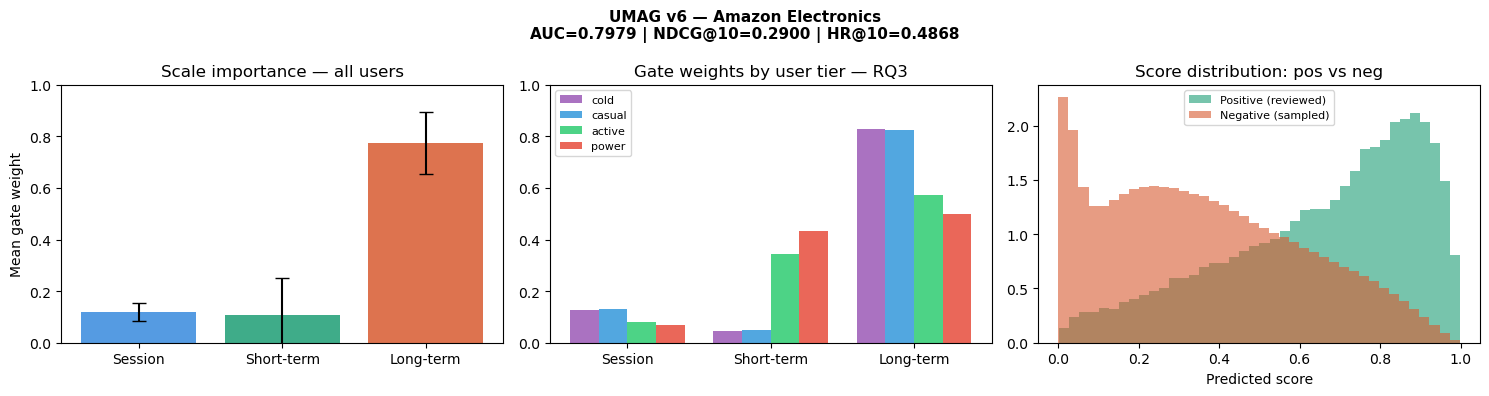


Saved: umag_amazon_v6_metrics.csv, umag_amazon_v6_gate.png


In [16]:
import matplotlib.pyplot as plt

# Load best checkpoint
best_path = Path(CFG["ckpt_dir"]) / "umag_amazon_best.pt"
if best_path.exists():
    obj = torch.load(best_path, map_location="cpu")
    model.load_state_dict(obj["model"])
    print(f"Loaded best checkpoint: epoch={obj['epoch']}, AUC={obj['val_auc']:.4f}")
model.eval()

# Full gate analysis on val set
rng_eval  = random.Random(99)
all_items_arr = ALL_ITEMS
n_items   = len(all_items_arr)
N_NEG_LOO = 99
ub, ib    = CFG["user_buckets"], CFG["item_buckets"]
S, M, L   = CFG["session_window"], CFG["short_window"], CFG["long_window"]
ssl       = M - S

all_preds, all_labels = [], []
all_gates, all_tiers  = [], []
eval_ranks = []

with torch.no_grad():
    for uid, hist in tqdm(val_history.items(), desc="Eval"):
        if len(hist) < 2:
            continue

        u_hash  = stable_hash(uid, ub)
        t_idx   = user_tier.get(uid, 1)
        context = hist[:-1]
        pos_entry = hist[-1]
        pos_item  = pos_entry[1]

        past_items = [h[1] for h in context]
        past_ws    = [h[2] for h in context]

        last_ts    = context[-1][0] if context else pos_entry[0]
        days_delta = max(0.0, (pos_entry[0] - last_ts) / SECS_PER_DAY)
        time_feat  = math.log1p(days_delta)

        seen_set  = set(h[1] for h in hist)
        neg_items = []
        attempts  = 0
        while len(neg_items) < N_NEG_LOO and attempts < N_NEG_LOO * 20:
            attempts += 1
            cand = all_items_arr[rng_eval.randrange(n_items)]
            if cand not in seen_set:
                neg_items.append(cand)
        if len(neg_items) < N_NEG_LOO:
            continue

        candidates = [pos_item] + neg_items
        n_cand     = len(candidates)

        sess_items  = past_items[-S:]
        sess_ws_    = past_ws[-S:]
        short_items = past_items[-(M):-S] if len(past_items) > S else []
        short_ws_   = past_ws[-(M):-S]    if len(past_ws)    > S else []
        long_items  = past_items[:-(M)]    if len(past_items) > M else []
        long_ws_    = past_ws[:-(M)]       if len(past_ws)    > M else []

        sess_pad  = pad_or_trim(sess_items,   S)
        short_pad = pad_or_trim(short_items, ssl)
        long_pad  = pad_or_trim(long_items,   L)
        sess_w_p  = pad_or_trim_w(sess_ws_,   S)
        short_w_p = pad_or_trim_w(short_ws_, ssl)
        long_w_p  = pad_or_trim_w(long_ws_,   L)

        if all(x == PAD for x in sess_pad):
            sess_pad  = short_pad[:S] if len(short_pad) >= S else short_pad + [PAD]*(S-len(short_pad))
            sess_w_p  = short_w_p[:S] if len(short_w_p) >= S else short_w_p + [0.0]*(S-len(short_w_p))

        u_t  = torch.tensor([u_hash]  * n_cand, dtype=torch.long).to(device)
        i_t  = torch.tensor(candidates,          dtype=torch.long).to(device)
        ti_t = torch.tensor([t_idx]   * n_cand, dtype=torch.long).to(device)
        s_t  = torch.tensor([sess_pad]  * n_cand, dtype=torch.long).to(device)
        sw_t = torch.tensor([sess_w_p]  * n_cand, dtype=torch.float32).to(device)
        sh_t = torch.tensor([short_pad] * n_cand, dtype=torch.long).to(device)
        shw_t= torch.tensor([short_w_p] * n_cand, dtype=torch.float32).to(device)
        l_t  = torch.tensor([long_pad]  * n_cand, dtype=torch.long).to(device)
        lw_t = torch.tensor([long_w_p]  * n_cand, dtype=torch.float32).to(device)
        tf_t = torch.tensor([time_feat] * n_cand, dtype=torch.float32).to(device)

        pred, gates, _, _, _ = model(
            u_t, i_t, ti_t, s_t, sw_t, sh_t, shw_t, l_t, lw_t, tf_t,
            return_weights=True
        )
        scores_np = pred.cpu().numpy()
        gates_np  = gates.cpu().numpy()

        rank = int((scores_np[1:] >= scores_np[0]).sum())
        eval_ranks.append(rank)

        all_preds.extend(scores_np.tolist())
        all_labels.extend([1.0] + [0.0] * N_NEG_LOO)
        # Use only the positive's gate weights for tier analysis
        all_gates.append(gates_np[0])
        all_tiers.append(t_idx)

EP = np.array(all_preds)
EL = np.array(all_labels)
EG = np.array(all_gates)
ET = np.array(all_tiers)

auc      = roc_auc_score(EL, EP) if len(set(EL)) > 1 else float("nan")
ndcg10, hr10 = compute_ndcg_hr(eval_ranks, k=10)

print("\n" + "="*60)
print("UMAG (MerRec arch v6) — AMAZON ELECTRONICS")
print("="*60)
print(f"  AUC-ROC    : {auc:.4f}")
print(f"  NDCG@10    : {ndcg10:.4f}")
print(f"  HR@10      : {hr10:.4f}")
print(f"  Eval users : {len(eval_ranks):,}")

gate_means = EG.mean(axis=0)
gate_stds  = EG.std(axis=0)
scale_names = [
    f"Session (last {CFG['session_window']})",
    f"Short   (last {CFG['short_window']})",
    f"Long    (all older)",
]
labels_short = ["Session", "Short-term", "Long-term"]
dominant = scale_names[int(np.argmax(gate_means))]

print("\n" + "="*60)
print("SCALE GATE WEIGHTS — RQ2")
print("="*60)
for name, m, s in zip(scale_names, gate_means, gate_stds):
    print(f"  {name:<30}: {m:.4f} ± {s:.4f}")
print(f"  Dominant: {dominant}")

print("\n" + "="*60)
print("GATE WEIGHTS BY USER TIER — RQ3")
print("="*60)
tier_gate_summary = {}
for ti, tname in enumerate(TIER_NAMES):
    mask = (ET == ti)
    if mask.sum() == 0: continue
    tg = EG[mask].mean(axis=0)
    tier_gate_summary[tname] = tg
    print(f"  {tname:<8} (n={mask.sum():>5,}): "
          f"Session={tg[0]:.4f}  Short={tg[1]:.4f}  Long={tg[2]:.4f}")

# ── Plots ────────────────────────────────────────────────────────
colors = ["#378ADD", "#1D9E75", "#D85A30"]
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].bar(labels_short, gate_means, color=colors, alpha=0.85)
axes[0].errorbar(labels_short, gate_means, yerr=gate_stds,
                 fmt="none", color="black", capsize=5)
axes[0].set_ylim(0, 1)
axes[0].set_ylabel("Mean gate weight")
axes[0].set_title("Scale importance — all users")

tier_colors = ["#9B59B6", "#3498DB", "#2ECC71", "#E74C3C"]
x = np.arange(3)
w = 0.2
for ti, tname in enumerate(TIER_NAMES):
    if tname not in tier_gate_summary: continue
    axes[1].bar(x + ti*w, tier_gate_summary[tname], w,
                label=tname, color=tier_colors[ti], alpha=0.85)
axes[1].set_xticks(x + w*1.5)
axes[1].set_xticklabels(labels_short)
axes[1].set_ylim(0, 1)
axes[1].set_title("Gate weights by user tier — RQ3")
axes[1].legend(fontsize=8)

# Score distribution
pos_scores = EP[EL == 1]
neg_scores = EP[EL == 0]
axes[2].hist(pos_scores, bins=40, alpha=0.6, label="Positive (reviewed)",
             color="#1D9E75", density=True)
axes[2].hist(neg_scores, bins=40, alpha=0.6, label="Negative (sampled)",
             color="#D85A30", density=True)
axes[2].set_xlabel("Predicted score")
axes[2].set_title("Score distribution: pos vs neg")
axes[2].legend(fontsize=8)

plt.suptitle(
    f"UMAG v6 — Amazon Electronics\n"
    f"AUC={auc:.4f} | NDCG@10={ndcg10:.4f} | HR@10={hr10:.4f}",
    fontsize=11, fontweight="bold"
)
plt.tight_layout()
plt.savefig("umag_amazon_v6_gate.png", dpi=150, bbox_inches="tight")
plt.show()

pd.DataFrame({
    "metric": ["auc_roc", "ndcg_at_10", "hr_at_10", "n_eval_users",
               "gate_session_mean", "gate_short_mean", "gate_long_mean",
               "dominant_scale"],
    "value":  [round(auc,4), round(ndcg10,4), round(hr10,4), len(eval_ranks),
               round(float(gate_means[0]),4),
               round(float(gate_means[1]),4),
               round(float(gate_means[2]),4),
               dominant]
}).to_csv("umag_amazon_v6_metrics.csv", index=False)
print("\nSaved: umag_amazon_v6_metrics.csv, umag_amazon_v6_gate.png")